In [1]:
import random as rnd
import numpy as np
import math
import matplotlib.pyplot as plt

Generowanie instacji problemu komiwojarzera

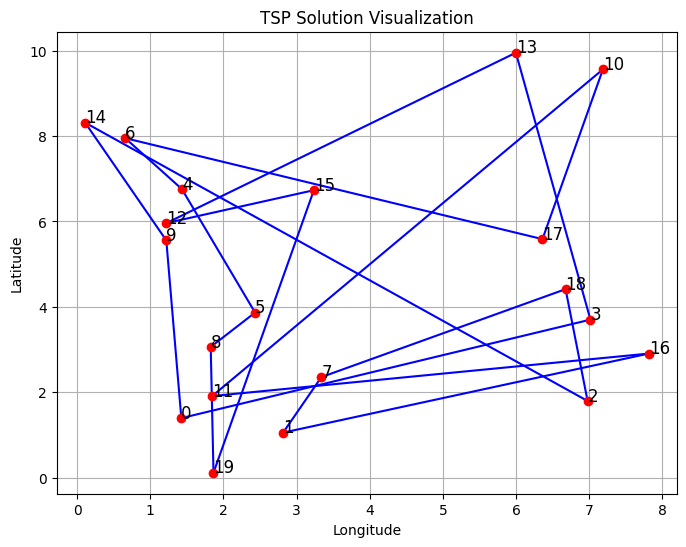

91.4960755381994


In [4]:
def generateInstace(n):
    lats = [rnd.random() * 10 for i in range(n)]
    lngs = [rnd.random() * 10 for i in range(n)]
    distance_matrix = np.zeros([n, n], dtype=float)
    for i in range(n):
        for j in range(n):
            distance_matrix[i, j] = math.sqrt((lats[j] - lats[i])**2 + (lngs[j] - lngs[i])**2)
    return [distance_matrix, lats, lngs]

def evaluate(pi, instance):
    last = pi[0]
    dist = 0.0
    for city in pi[1:]:
        dist += instance[0][last, city]
        last = city
    dist += instance[0][last, pi[0]]
    return dist

def plot_tsp_solution(pi, lats, lngs):
    plt.figure(figsize=(8, 6))
    for i in range(len(pi)):
        start_city = pi[i]
        end_city = pi[(i + 1) % len(pi)]
        plt.plot([lngs[start_city], lngs[end_city]], [lats[start_city], lats[end_city]], 'b-')

    plt.plot(lngs, lats, 'ro')
    for i, (x, y) in enumerate(zip(lngs, lats)):
        plt.text(x, y, str(i), color="black", fontsize=12)

    plt.title("TSP Solution Visualization")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid()
    plt.show()
n = 20
inst = generateInstace(n)
pi_rnd = list(range(n))
rnd.shuffle(pi_rnd)
plot_tsp_solution(pi_rnd, inst[1], inst[2])
print(evaluate(pi_rnd, inst))

Algortym najbliższego sąsiada

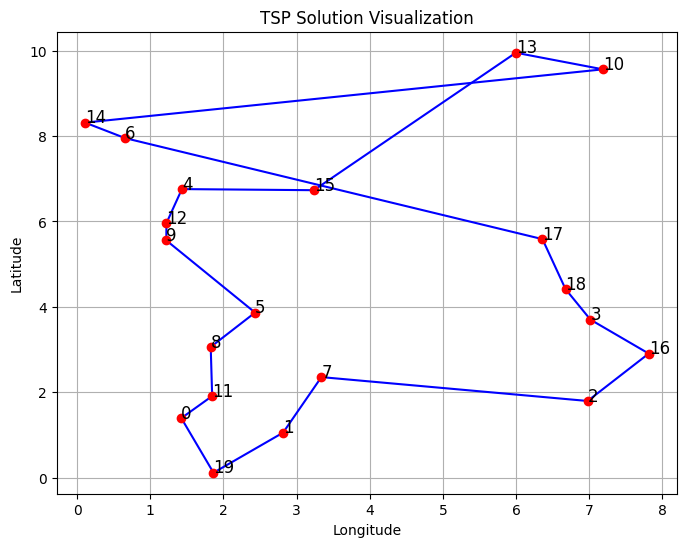

39.74828984732029


In [8]:
def nn(start, instance):
    n = instance[0].shape[0]
    pi = [start]
    visited = set(pi)

    for _ in range(n - 1):
        last_city = pi[-1]
        nearest_city = None
        nearest_dist = float('inf')
        for city in range(n):
            if city not in visited and instance[0][last_city, city] < nearest_dist:
                nearest_dist = instance[0][last_city, city]
                nearest_city = city

        pi.append(nearest_city)
        visited.add(nearest_city)

    return pi
pi_nn = nn(10, inst)
plot_tsp_solution(pi_nn, inst[1], inst[2])
print(evaluate(pi_nn, inst))

Algorytm wstawiania

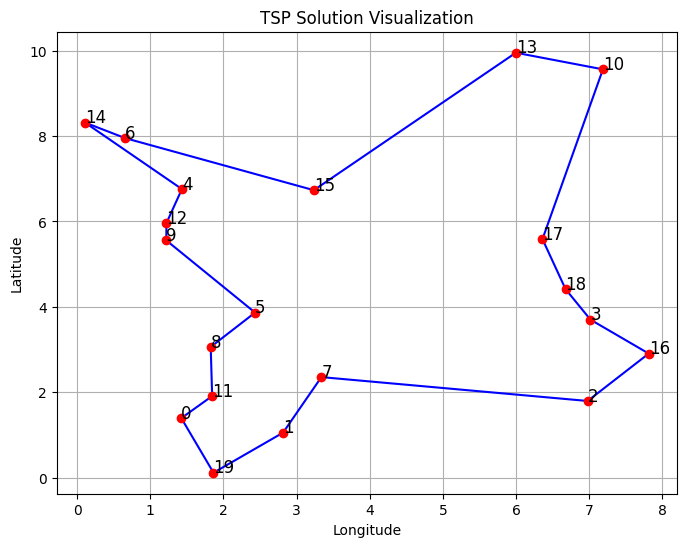

33.543116014775585


In [9]:
def insa(instance):
    n = instance[0].shape[0]
    pi = [rnd.randint(0, n - 1)]

    while len(pi) < n:
        best_insert_city = None
        best_position = None
        best_cost = float('inf')

        unvisited = [city for city in range(n) if city not in pi]
        new_city = rnd.choice(unvisited)

        for i in range(len(pi) + 1):
            new_pi = pi[:i] + [new_city] + pi[i:]
            cost = evaluate(new_pi, instance)
            if cost < best_cost:
                best_cost = cost
                best_position = i
        pi.insert(best_position, new_city)

    return pi
pi_insa = insa(inst)
plot_tsp_solution(pi_insa, inst[1], inst[2])
print(evaluate(pi_insa, inst))

Symulowane wyżarzanie

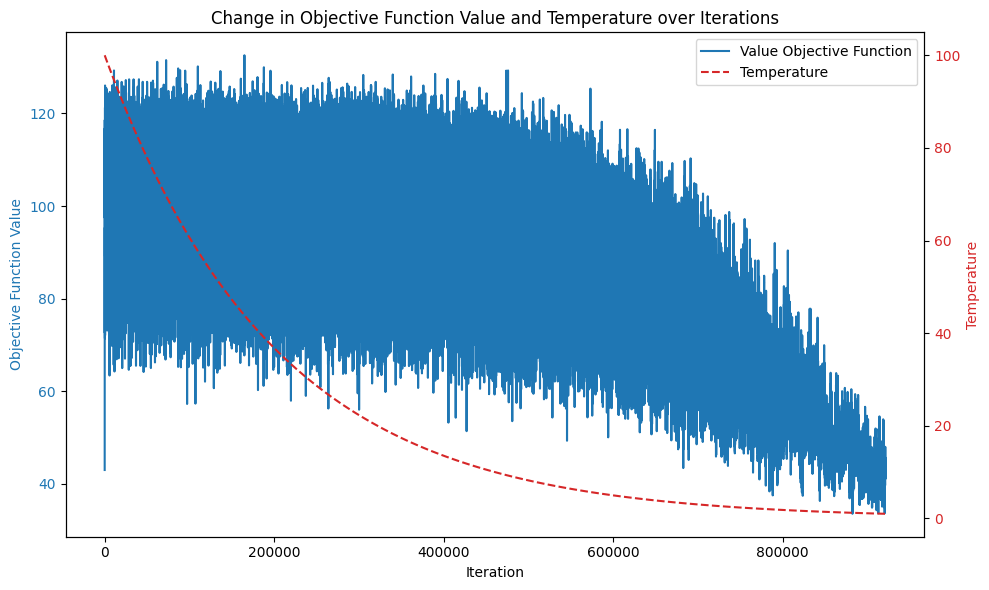

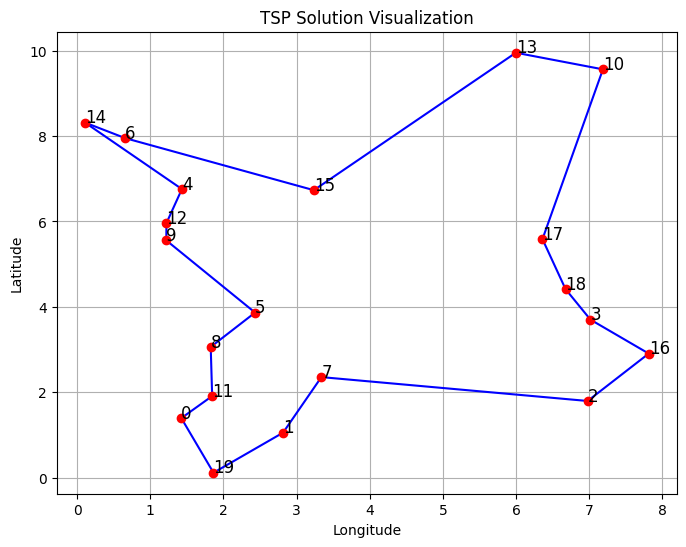

33.54311601477558


In [14]:
def sa(instance, pi_init , initial_temp, cooling_rate, verbose=True):
    n = len(instance[0])
    current_solution = pi_init
    best_solution = current_solution[:]
    current_cost = evaluate(current_solution, instance)
    best_cost = current_cost
    temperature = initial_temp

    iterations = []
    costs = []
    temps = []
    iter_count = 0
    while temperature > 1:
      for _ in range(10):
        iter_count += 1
        i, j = rnd.sample(range(1,n), 2)
        current_solution[i], current_solution[j] = current_solution[j], current_solution[i]

        new_cost = evaluate(current_solution, instance)
        delta_cost = new_cost - current_cost

        if delta_cost < 0 or rnd.random() < math.exp(-delta_cost / temperature):
            current_cost = new_cost
            if current_cost < best_cost:
                best_solution = current_solution[:]
                best_cost = current_cost
        else:
            current_solution[i], current_solution[j] = current_solution[j], current_solution[i]
        iterations.append(iter_count)
        costs.append(current_cost)
        temps.append(temperature)
      temperature *= cooling_rate
    if verbose:
      fig, ax_cost = plt.subplots(figsize=(10,6))

      ax_cost.plot(iterations, costs, color='tab:blue', label='Value Objective Function')
      ax_cost.set_xlabel('Iteration')
      ax_cost.set_ylabel('Objective Function Value', color='tab:blue')
      ax_cost.tick_params(axis='y', labelcolor='tab:blue')

      ax_temp = ax_cost.twinx()
      ax_temp.plot(iterations, temps, color='tab:red', linestyle='--', label='Temperature')
      ax_temp.set_ylabel('Temperature', color='tab:red')
      ax_temp.tick_params(axis='y', labelcolor='tab:red')

      # legenda łączona
      lines_cost, labels_cost = ax_cost.get_legend_handles_labels()
      lines_temp, labels_temp = ax_temp.get_legend_handles_labels()
      ax_cost.legend(lines_cost + lines_temp, labels_cost + labels_temp, loc='upper right')

      plt.title('Change in Objective Function Value and Temperature over Iterations')
      plt.tight_layout()
      plt.show()
    return best_solution
pi_sa = sa(inst, pi_rnd, 100.0, 0.99995)
plot_tsp_solution(pi_sa, inst[1], inst[2])
print(evaluate(pi_sa, inst))

Algorytm mrówkowy

# Algorytmy mrówkowe  — teoria i ewolucja

Algorytmy mrówkowe wywodzą się z obserwacji zachowania prawdziwych mrówek. Jest to probabilistyczna metoda optymalizacji, w której sztuczne „mrówki” budują rozwiązania poprzez poruszanie się po grafie i wykorzystanie feromonów jako pamięci zbiorowej. Pierwsza implemetnacja powstała jako Ant system (Marco Dorigo 1991/1992).
Kluczowe zjawiska:
- mrówki poruszają się losowo
- zostawiają ślad feromonowy
- krótsze ścieżki są wzmacniane szybciej
- system sam organizuje się globalnie
- brak centralnego sterowania


Każda $k$-mrówka buduje rozwiązanie krok po kroku (iteracyjne). 
* stan = częściowe rozwiązanie
* przejście = wybór kolejnego elementu

Prawdopodobieństwo wyboru:

$ p_{xy}^k = \frac{(\tau_{xy})^{\alpha} (\eta_{xy})^{\beta}}{\sum_{z \in allowed} (\tau_{xz})^{\alpha} (\eta_{xz})^{\beta}} $,

gdzie:

* $ \tau_{xy} $ – poziom feromonu
* $ \eta_{xy} $ – heurystyka (np. (1/d))
* $ \alpha \ge 0 $ – wpływ feromonu
* $ \beta \ge 1 $ – wpływ heurystyki

Poziom feromonu odpowaida za widzę historyczną a herysytka za wiedzę lokalną.

Aktualizacja feromonu (globalna)

$ \tau_{xy} \leftarrow (1 - \rho)\tau_{xy} + \sum_{k=1}^{m} \Delta \tau_{xy}^k $,

gdzie:
* $ \rho $ – współczynnik parowania,
* $ m $ – liczba mrówek.

$
\Delta \tau_{xy}^k =
\begin{cases}
\frac{Q}{L_k} & \text{jeśli k używa krawędzi} \\
0 & \text{w przeciwnym razie}
\end{cases}
$

gdzie:
* $ L_k $ – koszt rozwiązania znaleziony przez $k$-tą mrówkę,
* $ Q $ – stała.

<img src="img/ant.jpeg" width="800">

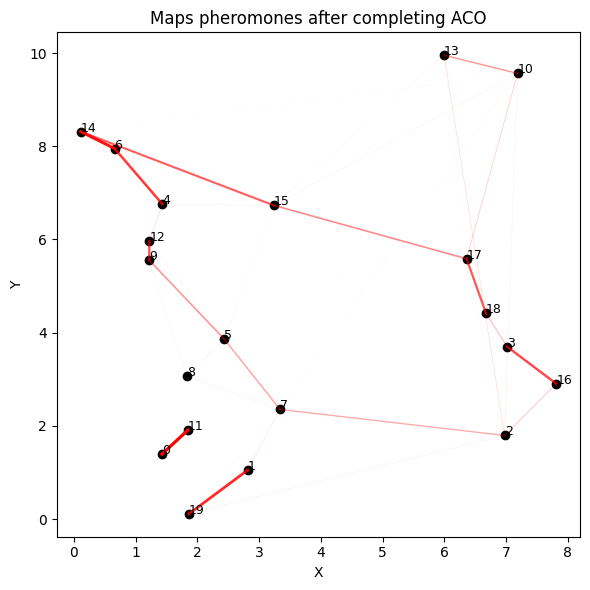

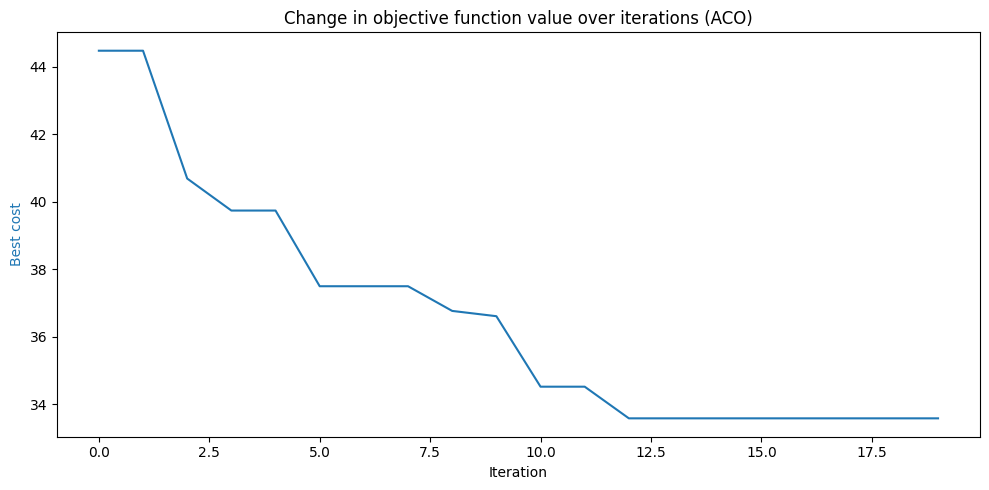

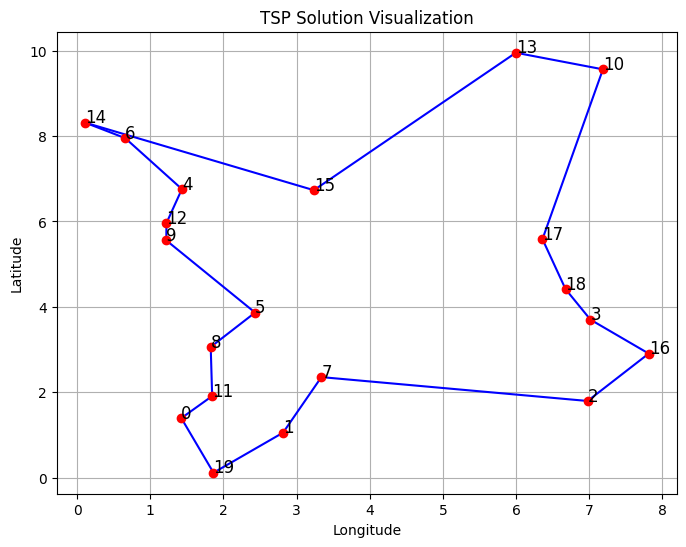

33.575075431544825


In [19]:
def AS(inst, n_ants=20, n_iter=50, alpha=1.0, beta=2.0, rho=0.5, verbose=True):
    n = len(inst[0])

    tau = np.ones((n,n))

    best_costs = []

    def choose_next(cur, visited):
        probs = []
        for j in range(n):
            if j not in visited:
                heuristic = 1 / (inst[0][cur,j] + 1e-6)
                probs.append((j, (tau[cur,j]**alpha) * (heuristic**beta)))
        S = sum(p for _,p in probs)
        r = rnd.random() * S
        cum = 0
        for city, p in probs:
            cum += p
            if r <= cum:
                return city
        return probs[-1][0]

    best_route = None
    best_cost  = float("inf")

    for _ in range(n_iter):
        all_routes = []
        all_costs  = []

        for _ in range(n_ants):
            cur = 0
            visited = {0}
            route = [0]

            while len(visited) < n:
                nxt = choose_next(cur, visited)
                route.append(nxt)
                visited.add(nxt)
                cur = nxt

            route.append(0)
            cost = evaluate(route, inst)

            all_routes.append(route)
            all_costs.append(cost)

            if cost < best_cost:
                best_cost = cost
                best_route = route
        best_costs.append(best_cost)
        tau *= (1 - rho)
        for route,cost in zip(all_routes, all_costs):
            if cost < float("inf"):
                for i in range(len(route)-1):
                    a = route[i]; b = route[i+1]
                    tau[a,b] += 1.0 / cost
    if verbose:
        plt.figure(figsize=(6, 6))
        plt.title("Maps pheromones after completing ACO")
        tmin, tmax = np.min(tau), np.max(tau)
        norm = (tau - tmin) / (tmax - tmin + 1e-9)
        
        for i in range(n):
            for j in range(i+1, n):
                intensity = norm[i, j]
                if intensity > 0:
                    plt.plot(
                        [inst[2][i], inst[2][j]],
                        [inst[1][i], inst[1][j]],
                        color=(1, 0, 0, intensity),  # RGBA – im więcej feromonu, tym bardziej czerwone
                        linewidth=2 * intensity + 0.3
                    )

        #
        plt.scatter(inst[2], inst[1], c='black')
        for i in range(n):
            plt.text(inst[2][i], inst[1][i], str(i), fontsize=9)

        plt.xlabel("X")
        plt.ylabel("Y")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.plot(range(n_iter), best_costs, color='tab:blue')
        plt.xlabel("Iteration")
        plt.ylabel("Best cost", color='tab:blue')
        plt.title("Change in objective function value over iterations (ACO)")
        plt.tight_layout()
        plt.show()

    return best_route
pi_aco = AS(inst, 50, 20, rho=0.3, beta= 2)
plot_tsp_solution(pi_aco, inst[1], inst[2])
print(evaluate(pi_aco, inst))

# 🐜 Ewolucja algorytmów mrówkowych (ACO)

##  1. Ant System (AS)

**Pierwsza wersja algorytmu ACO (Dorigo, 1992)**

### Cechy:
- wszystkie mrówki budują rozwiązania
- wszystkie aktualizują feromon
- wybór probabilistyczny

### Problemy:
- wolna zbieżność
- duży szum
- stagnacja

---

##  2. Ant Colony System (ACS)

### Kluczowe ulepszenia:

#### 1. Eksploatacja vs eksploracja
- parametr `q0`
- greedy wybór lub losowanie

#### 2. Lokalna aktualizacja feromonu
- zmniejszanie feromonu podczas budowy rozwiązania

#### 3. Globalna aktualizacja tylko najlepszej mrówki

### Efekt:
- szybsza konwergencja
- lepsza kontrola eksploracji

---

##  3. Elitist Ant System

### Idea:
- najlepsza globalna trasa dostaje dodatkowy feromon

### Cel:
- skierowanie całej populacji w stronę najlepszego rozwiązania

---

##  4. Max-Min Ant System (MMAS)

### Kluczowe elementy:

#### Ograniczenie feromonów:
τ_min ≤ τ_ij ≤ τ_max

#### Aktualizacja:
- tylko najlepsza trasa (globalna lub iteracyjna)

#### Dodatkowo:
- restart przy stagnacji
- inicjalizacja τ_max

### Zalety:
- stabilność
- brak stagnacji
- bardzo dobre wyniki

---

##  5. Rank-Based Ant System (ASrank)

### Idea:
- tylko najlepsze mrówki aktualizują feromon
- różne wagi dla różnych rozwiązań

### Efekt:
- redukcja szumu
- lepsza selekcja

---

##  6. Parallel ACO (PACO)

### Idea:
- równoległe kolonie mrówek

### Mechanizm:
- podział na grupy
- komunikacja między nimi

### Zalety:
- przyspieszenie
- lepsza eksploracja

---

##  7. Continuous Orthogonal ACO (COAC)

### Zastosowanie:
- problemy ciągłe

### Cechy:
- projektowanie ortogonalne
- adaptacyjny zakres przeszukiwania

---

##  8. Recursive ACO

### Idea:
- dzielenie problemu na podobszary

### Mechanizm:
1. podział przestrzeni
2. rozwiązanie lokalne
3. selekcja najlepszych
4. dalsza rekurencja

### Efekt:
- większa dokładność
- skalowalność

---

##  Podsumowanie

| Algorytm | Problem | Rozwiązanie |
|----------|--------|------------|
| AS | wolny, niestabilny | baza |
| ACS | brak kontroli | eksploracja/eksploatacja |
| Elitist | brak kierunku | wzmocnienie best |
| MMAS | stagnacja | ograniczenia |
| ASrank | szum | ranking |
| PACO | wydajność | równoległość |
| COAC | przestrzeń ciągła | eksploracja |
| Recursive | skalowalność | dekompozycja |

---

##  Wniosek

Ewolucja ACO polega na:
- ograniczaniu wpływu słabych rozwiązań
- zwiększaniu kontroli eksploracji
- poprawie stabilności i skalowalności